## Przygotowanie obrazów do eksperymentów

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
from PIL import Image
import adom_library as adom
import adom_images as images

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


In [2]:
test_dataset = adom.get_CIFAR10_dataset(
    train_dataset=False,
    perform_transform=False
)

classes = test_dataset.classes

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Wybór obrazu, który zostanie zmodyfikowany na wiele sposobów do eksperymentów

In [3]:
img, label = test_dataset[1]

print("True class:", classes[label])

True class: ship


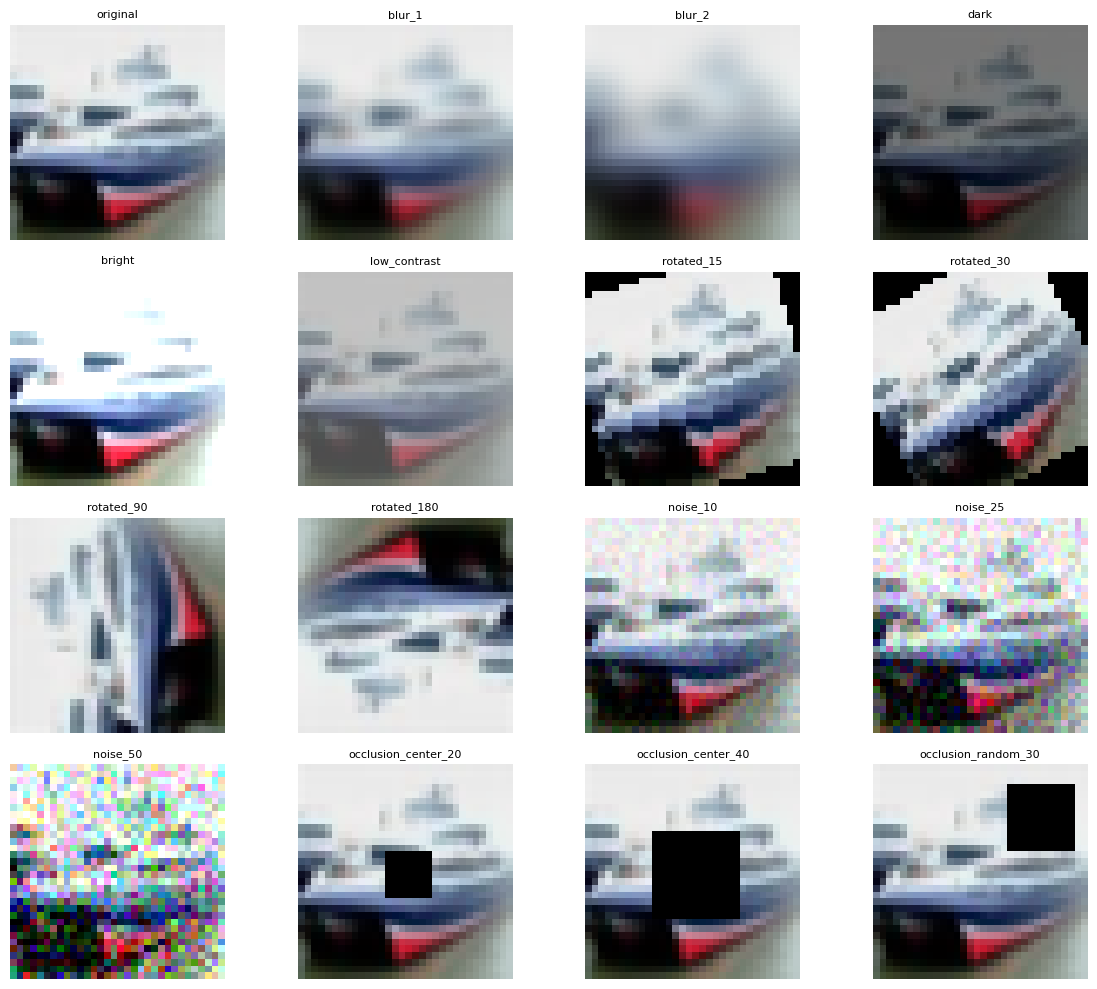

In [4]:
variants = {
    "original": img,
    "blur_1": images.apply_blur(img, 1),
    "blur_2": images.apply_blur(img, 2),
    "dark": images.apply_brightness(img, 0.5),
    "bright": images.apply_brightness(img, 1.5),
    "low_contrast": images.apply_contrast(img, 0.5),
    "rotated_15": images.apply_rotation(img, 15),
    "rotated_30": images.apply_rotation(img, 30),
    "rotated_90": images.apply_rotation(img, 90),
    "rotated_180": images.apply_rotation(img, 180),

    "noise_10": images.apply_noise(img, std=10),
    "noise_25": images.apply_noise(img, std=25),
    "noise_50": images.apply_noise(img, std=50),

    "occlusion_center_20": images.apply_occlusion(img, size_ratio=0.2),
    "occlusion_center_40": images.apply_occlusion(img, size_ratio=0.4),
    "occlusion_random_30": images.apply_occlusion(img, size_ratio=0.3, position="random"),
}

images.show_structured_images(variants)

In [5]:
images.save_image_variants(variants)

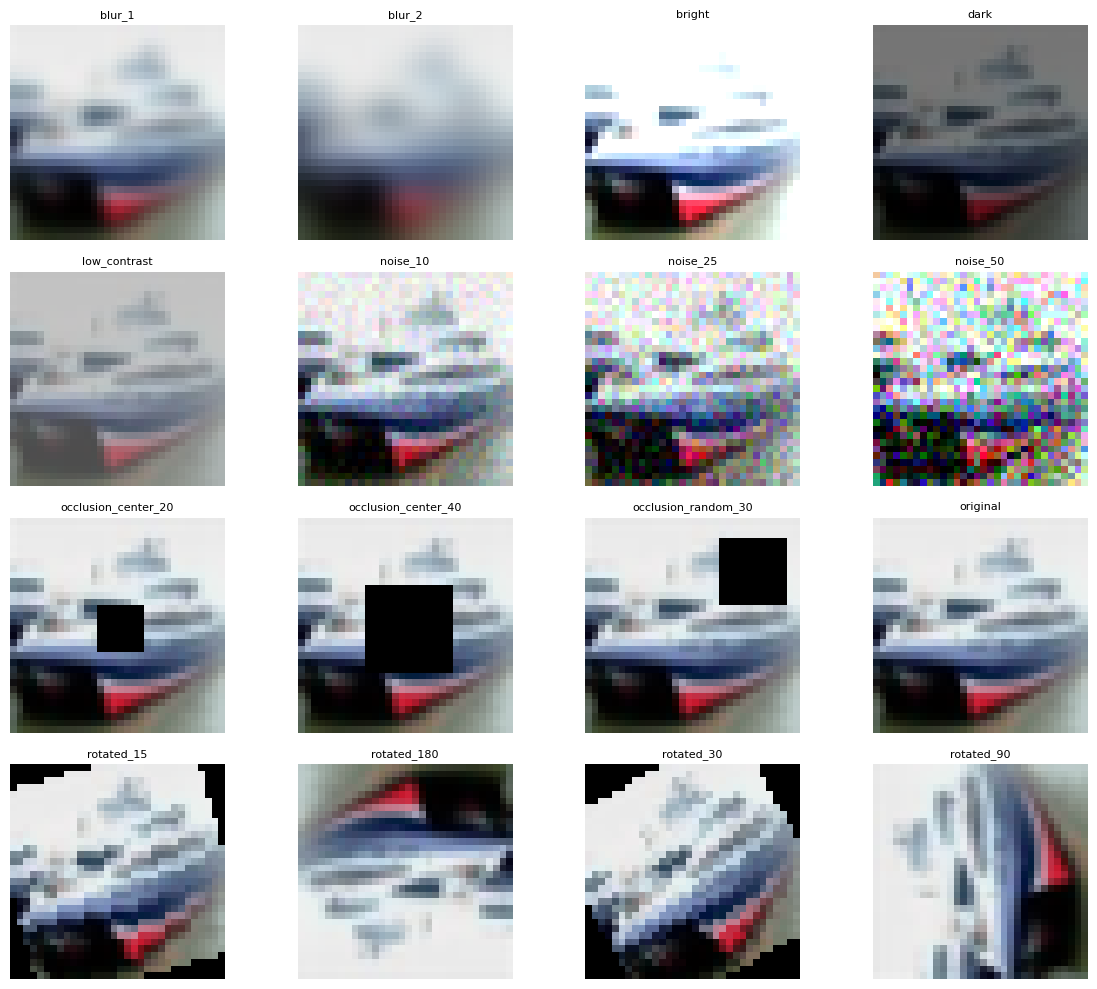

In [6]:
variants_loaded = images.load_image_variants()
images.show_structured_images(variants_loaded)

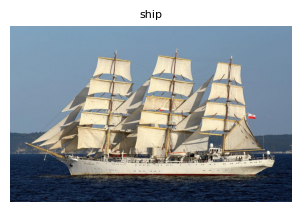

In [7]:
external_images = images.load_external_images()
images.show_structured_images(external_images)